In [7]:
# Instalar LightGBM directamente desde el notebook
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.6 MB/s  0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración estética
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

# 1. Carga de datos
input_path = '../data/Filtered.pkl' # Asegúrate de haber guardado el df_filtered del notebook anterior con este nombre

print("📥 Cargando dataset para modelado...")
if os.path.exists(input_path):
    df = pd.read_pickle(input_path)
    print(f"✅ Dataset cargado correctamente: {df.shape[0]} filas y {df.shape[1]} columnas.")
else:
    print(f"❌ Error: No se encontró el archivo en {input_path}")

# Vista rápida
display(df.head(3))

📥 Cargando dataset para modelado...
✅ Dataset cargado correctamente: 114567 filas y 15 columnas.


,order_id,is_delayed,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114567 entries, 0 to 119142
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        114567 non-null  object 
 1   is_delayed                      114567 non-null  int64  
 2   estimated_delivery_margin_days  114567 non-null  int64  
 3   purchase_month                  114567 non-null  int32  
 4   purchase_day_of_week            114567 non-null  int32  
 5   product_weight_g                114567 non-null  float64
 6   product_volume_cm3              114567 non-null  float64
 7   product_category_name_english   114567 non-null  object 
 8   customer_zip_code_prefix        114567 non-null  int64  
 9   seller_zip_code_prefix          114567 non-null  float64
 10  is_same_state                   114567 non-null  int64  
 11  customer_state_num_pred         114567 non-null  int64  
 12  seller_state_num_pred

In [ ]:
# 1. Selección de variables y limpieza de identificadores
# Eliminamos 'order_id' (no predictivo) y el target. 
# Añadimos errors='ignore' para que no falle si las columnas de lat/lng no existen en este paso.
features_to_drop = ['order_id', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']
X = df.drop(columns=features_to_drop + ['is_delayed'], errors='ignore')
y = df['is_delayed']

# 2. Definición de variables categóricas
# LightGBM funciona mejor si le indicamos explícitamente cuáles son categorías
cat_cols = [
    'product_category_name_english', 
    'customer_state_num_pred', 
    'seller_state_num_pred',
    'purchase_month', 
    'purchase_day_of_week',
    'is_same_state'
]

for col in cat_cols:
    X[col] = X[col].astype('category')

print(f"✅ Codificación completada. Variables predictoras: {X.shape[1]}")
print(f"Columnas categóricas detectadas: {cat_cols}")

✅ Codificación completada. Variables predictoras: 13
Columnas categóricas detectadas: ['product_category_name_english', 'customer_state_num_pred', 'seller_state_num_pred', 'purchase_month', 'purchase_day_of_week', 'is_same_state']


In [4]:
# Cálculo del balance de clases
num_neg = (y == 0).sum()
num_pos = (y == 1).sum()

# El peso ideal es la proporción de negativos sobre positivos
scale_pos_weight = num_neg / num_pos

print(f"📊 Análisis de Balance:")
print(f" - Pedidos a tiempo (0): {num_neg}")
print(f" - Pedidos retrasados (1): {num_pos}")
print(f" - Factor 'scale_pos_weight' recomendado: {scale_pos_weight:.2f}")
print("\nEste valor se pasará como parámetro al modelo para compensar el desequilibrio.")

📊 Análisis de Balance:
 - Pedidos a tiempo (0): 105642
 - Pedidos retrasados (1): 8925
 - Factor 'scale_pos_weight' recomendado: 11.84

Este valor se pasará como parámetro al modelo para compensar el desequilibrio.


In [5]:
from sklearn.model_selection import train_test_split

# 1. Primero separamos un 15% para el Test final (datos nunca vistos)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# 2. Del 85% restante, separamos otro 15% para Verificación/Validación
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, stratify=y_train_val, random_state=42
)

print("📈 División de datos finalizada (72% / 13% / 15%):")
print(f" - Entrenamiento (Train): {X_train.shape[0]} registros")
print(f" - Validación (Val): {X_val.shape[0]} registros")
print(f" - Prueba (Test): {X_test.shape[0]} registros")

📈 División de datos finalizada (72% / 13% / 15%):
 - Entrenamiento (Train): 82773 registros
 - Validación (Val): 14608 registros
 - Prueba (Test): 17186 registros


In [12]:
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("🚀 Iniciando modelo LightGBM enfocado en Maximizar F1-Score...")

# 🚨 CLAVE F1: Suavizamos el peso de la clase minoritaria.
# Usar la raíz cuadrada del desbalance es un estándar en la industria para maximizar el F1.
# Si tu scale_pos_weight era ~12, f1_weight será ~3.4
f1_weight = scale_pos_weight ** 0.5 

# 1. Definición de Hiperparámetros Optimizados para F1
lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',                    
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'n_estimators': 1500,               
    'num_leaves': 63,                   # SUBIMOS: Mayor complejidad para hilar más fino y ganar Precisión
    'max_depth': 8,                     # SUBIMOS: Permitimos árboles más profundos
    'min_child_samples': 50,            # BAJAMOS: Hojas más específicas (menos generalización bruta)
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': f1_weight,      # Usamos el peso equilibrado
    'random_state': 42,
    'n_jobs': -1
}

# 2. Instanciar el modelo
model_lgb = lgb.LGBMClassifier(**lgbm_params)

print("⏳ Entrenando...")

# 3. Entrenamiento con Early Stopping estricto
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Entrenamiento', 'Validacion'],
    categorical_feature=cat_cols,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\n✅ Entrenamiento finalizado.")
print(f"🌲 Número de árboles creados óptimamente: {model_lgb.best_iteration_}")

🚀 Iniciando modelo LightGBM enfocado en Maximizar F1-Score...
⏳ Entrenando...
[LightGBM] [Info] Number of positive: 6448, number of negative: 76325
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001533 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1757
[LightGBM] [Info] Number of data points in the train set: 82773, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.077900 -> initscore=-2.471231
[LightGBM] [Info] Start training from score -2.471231
Training until validation scores don't improve for 100 rounds
[50]	Entrenamiento's auc: 0.863532	Validacion's auc: 0.815797
[100]	Entrenamiento's auc: 0.891532	Validacion's auc: 0.824192
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

💾 1. GUARDANDO EL MODELO...
✅ Modelo guardado exitosamente en: ../models/lgbm_logistics_model.pkl

🎯 2. EVALUANDO EN EL CONJUNTO DE TEST...
----------------------------------------
🔹 Accuracy (Exactitud):  0.9184 (Recuerda: puede ser engañosa)
🔹 Precision (Precisión): 0.4718 (De los que predijo retraso, % que realmente lo fue)
🔹 Recall (Sensibilidad): 0.4003 (De TODOS los retrasos reales, % que logró detectar)
🔹 F1-Score:              0.4331 (El equilibrio entre Precisión y Recall)
🔹 ROC-AUC:               0.8339 (Capacidad general de separar las dos clases)
----------------------------------------

📋 REPORTE DE CLASIFICACIÓN DETALLADO:
               precision    recall  f1-score   support

 A Tiempo (0)       0.95      0.96      0.96     15847
Retrasado (1)       0.47      0.40      0.43      1339

     accuracy                           0.92     17186
    macro avg       0.71      0.68      0.69     17186
 weighted avg       0.91      0.92      0.92     17186



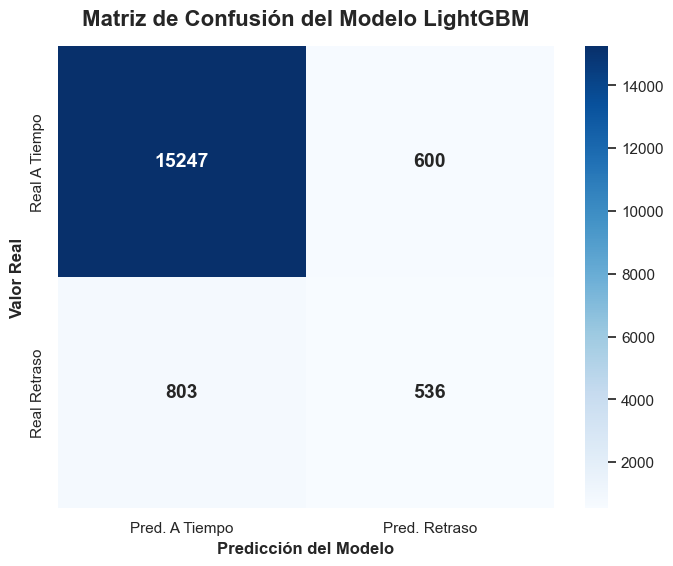

In [13]:
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)

print("💾 1. GUARDANDO EL MODELO...")
# Crear el directorio si no existe
os.makedirs('../models', exist_ok=True)
model_path = '../models/lgbm_logistics_model.pkl'

# Guardar el modelo usando joblib
joblib.dump(model_lgb, model_path)
print(f"✅ Modelo guardado exitosamente en: {model_path}\n")

print("🎯 2. EVALUANDO EN EL CONJUNTO DE TEST...")
# Generar predicciones (0 o 1) y probabilidades (0.0 a 1.0)
y_pred = model_lgb.predict(X_test)
y_prob = model_lgb.predict_proba(X_test)[:, 1] # Probabilidad de pertenecer a la clase 1 (Retraso)

# Calcular métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Imprimir el resumen ejecutivo
print("-" * 40)
print(f"🔹 Accuracy (Exactitud):  {acc:.4f} (Recuerda: puede ser engañosa)")
print(f"🔹 Precision (Precisión): {prec:.4f} (De los que predijo retraso, % que realmente lo fue)")
print(f"🔹 Recall (Sensibilidad): {rec:.4f} (De TODOS los retrasos reales, % que logró detectar)")
print(f"🔹 F1-Score:              {f1:.4f} (El equilibrio entre Precisión y Recall)")
print(f"🔹 ROC-AUC:               {auc:.4f} (Capacidad general de separar las dos clases)")
print("-" * 40)

print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(y_test, y_pred, target_names=['A Tiempo (0)', 'Retrasado (1)']))

# 3. VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Crear el heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred. A Tiempo', 'Pred. Retraso'], 
            yticklabels=['Real A Tiempo', 'Real Retraso'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión del Modelo LightGBM', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.show()